In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt


In [5]:

df = pd.read_csv("/home/jovyan/2026-proj-hypoxia-zones/data/sat_matchups/Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.csv")


In [6]:
y = df["oxygen"]

# predictors: ONLY multivariate wavelengths
wl_cols = [c for c in df.columns if c.startswith("PRrs")]
X = df[wl_cols]

In [7]:
mask = X.notnull().all(axis=1) & y.notnull()
X = X.loc[mask]
y = y.loc[mask]

print("Samples used:", len(y))
print("Number of wavelengths:", len(wl_cols))


Samples used: 853
Number of wavelengths: 172


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
model = Pipeline([
    ("scaler", StandardScaler()),   # scale PRrs wavelengths
    ("ridge", Ridge(alpha=10.0))    # L2-regularized linear regression
])

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)


# evaluate
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

[5.79395803 4.82790903 5.82178365 5.5433502  4.92479538 4.72080461
 4.68718697 5.46686553 4.9738382  5.42880748 4.73470979 5.79520851
 5.41188665 5.57492579 4.34522578 4.01791313 4.53455462 4.63737934
 5.69845185 5.00217352 4.27768688 4.49739777 4.72148861 4.89744761
 5.20284094 4.96240991 5.99578812 4.49670644 4.65489223 5.4929896
 5.59765474 4.54897138 4.75673236 6.28872801 4.71272676 4.55158502
 4.89247215 5.67023426 4.75967067 5.7420538  4.83648017 4.97879091
 4.60653465 4.35011795 5.5030529  4.23785814 4.97526268 4.09441564
 6.27764482 5.53237322 4.58004911 4.51135463 5.0609705  5.46802747
 4.56060286 5.55609714 5.85744802 5.85186888 5.79346762 5.17260459
 4.36025989 5.75556912 4.46356378 5.79166568 4.93754931 5.11709531
 4.76859796 5.76705005 5.37831418 4.25330771 4.30318078 4.46614619
 4.64722884 4.40200519 4.25605662 5.50308076 5.46436215 5.01476654
 4.45124804 4.97042612 4.8661508  4.59308628 4.78671767 5.40595278
 5.6159299  4.70668918 5.59176334 5.45501595 4.72825872 5.14770

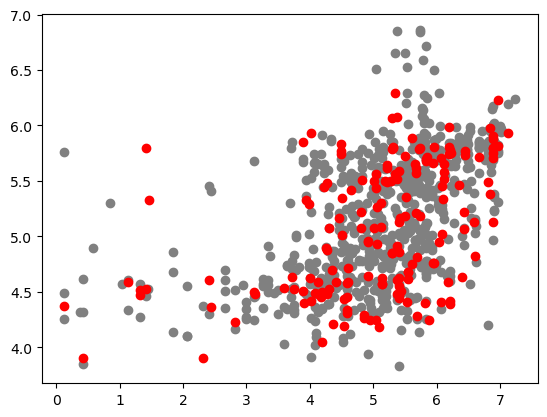

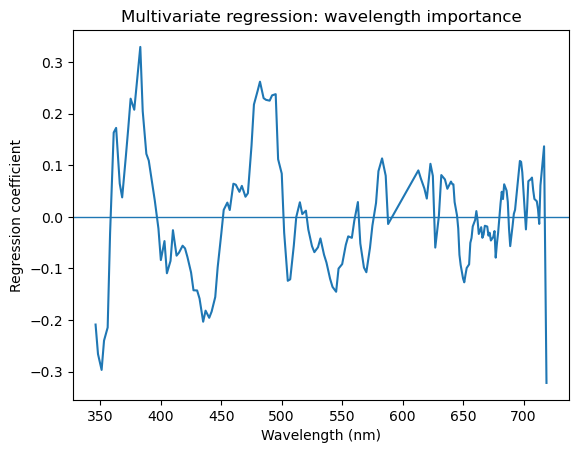

In [18]:
coef = model.named_steps["ridge"].coef_
coef_s = pd.Series(coef, index=wl_cols)

# numeric wavelengths for plotting
wavelengths = np.array([int(c.replace("PRrs", "")) for c in wl_cols])
order = np.argsort(wavelengths)

##
plt.figure
plt.scatter(y_train, y_pred_train, color = "grey")
plt.scatter(y_test, y_pred, color = "red")
plt.show()

plt.plot(wavelengths[order], coef_s.values[order])
plt.axhline(0, linewidth=1)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Regression coefficient")
plt.title("Multivariate regression: wavelength importance")
plt.show()